In [3]:
# =====================================================================
# TASK 1: DATASET UNDERSTANDING
# =====================================================================
import pandas as pd
import numpy as np

# 1. Load the datasets into Python (Pandas)
netflix_df = pd.read_csv("netflix_titles.csv")
retail_df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1")

print("=====================================================================")
print("🎬 NETFLIX DATASET UNDERSTANDING")
print("=====================================================================")
# 2. Display the first few rows
print("\n--- FIRST 3 ROWS ---")
display(netflix_df.head(3))

# 3. Identify dimensions and attributes
print(f"\nDimensions: {netflix_df.shape[0]} Rows | {netflix_df.shape[1]} Columns")
print("\n--- DATA TYPES ---")
print(netflix_df.dtypes)

print("\n--- CHARACTERISTICS SUMMARY ---")
print("- Possible Unique Identifier (Primary Key): 'show_id'")
print("- Numerical features: 'release_year'")
print("- Categorical features: 'type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description'")
print("- Temporal feature: 'date_added'")

print(f"\n4. Description: Contains metadata describing {netflix_df.shape[0]:,} video titles on Netflix, tracking cast, country, release year, age ratings, and genre classification.")

print("\n=====================================================================")
print("🛒 E-COMMERCE DATASET UNDERSTANDING")
print("=====================================================================")
# 2. Display the first few rows
print("\n--- FIRST 3 ROWS ---")
display(retail_df.head(3))

# 3. Identify dimensions and attributes
print(f"\nDimensions: {retail_df.shape[0]} Rows | {retail_df.shape[1]} Columns")
print("\n--- DATA TYPES ---")
print(retail_df.dtypes)

print("\n--- CHARACTERISTICS SUMMARY ---")
print("- Possible Unique Identifier (Primary Key): Composite key ('InvoiceNo' + 'StockCode')")
print("- Numerical features: 'Quantity', 'UnitPrice', 'CustomerID'")
print("- Categorical features: 'InvoiceNo', 'StockCode', 'Description', 'Country'")
print("- Temporal feature: 'InvoiceDate'")

print(f"\n4. Description: This dataset contains {retail_df.shape[0]:,} raw corporate transactional rows tracking {', '.join(retail_df.columns.tolist())}.")

🎬 NETFLIX DATASET UNDERSTANDING

--- FIRST 3 ROWS ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...



Dimensions: 8807 Rows | 12 Columns

--- DATA TYPES ---
show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

--- CHARACTERISTICS SUMMARY ---
- Possible Unique Identifier (Primary Key): 'show_id'
- Numerical features: 'release_year'
- Categorical features: 'type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description'
- Temporal feature: 'date_added'

4. Description: Contains metadata describing 8,807 video titles on Netflix, tracking cast, country, release year, age ratings, and genre classification.

🛒 E-COMMERCE DATASET UNDERSTANDING

--- FIRST 3 ROWS ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom



Dimensions: 541909 Rows | 8 Columns

--- DATA TYPES ---
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

--- CHARACTERISTICS SUMMARY ---
- Possible Unique Identifier (Primary Key): Composite key ('InvoiceNo' + 'StockCode')
- Numerical features: 'Quantity', 'UnitPrice', 'CustomerID'
- Categorical features: 'InvoiceNo', 'StockCode', 'Description', 'Country'
- Temporal feature: 'InvoiceDate'

4. Description: This dataset contains 541,909 raw corporate transactional rows tracking InvoiceNo, StockCode, Description, Quantity, InvoiceDate, UnitPrice, CustomerID, Country.


In [5]:
# =====================================================================
# TASK 2: DATA CLEANING & VALIDATION
# =====================================================================

print("=====================================================================")
print("DETECTING ISSUES (PRE-CLEAN)")
print("=====================================================================")
print("\n--- NETFLIX MISSING VALUES ---")
print(netflix_df.isnull().sum())
print(f"Total Duplicate Rows Found: {netflix_df.duplicated().sum()}")

print("\n--- E-COMMERCE MISSING VALUES ---")
print(retail_df.isnull().sum())
print(f"Total Duplicate Rows Found: {retail_df.duplicated().sum()}")

# --- PERFORM CLEANING ACTIONS ---

# 1. Clean Netflix Data
netflix_cleaned = netflix_df.copy()
netflix_cleaned['director'] = netflix_cleaned['director'].fillna('Unknown') # Filled text placeholders
netflix_cleaned['cast'] = netflix_cleaned['cast'].fillna('Unknown')
netflix_cleaned['country'] = netflix_cleaned['country'].fillna(netflix_cleaned['country'].mode()[0]) # Mode Imputation

# Standardization & Date Handling
netflix_cleaned['date_added'] = pd.to_datetime(netflix_cleaned['date_added'].str.strip(), errors='coerce')
netflix_cleaned = netflix_cleaned.dropna(subset=['date_added', 'rating', 'duration'])
netflix_cleaned['type'] = netflix_cleaned['type'].str.strip().str.title()
netflix_cleaned['year_added'] = netflix_cleaned['date_added'].dt.year

# 2. Clean E-commerce Data
retail_cleaned = retail_df.copy()
retail_cleaned['Description'] = retail_cleaned['Description'].fillna('No Description').str.strip().str.upper()
retail_cleaned['CustomerID'] = retail_cleaned['CustomerID'].fillna(-1) # Handle missing customer IDs without removing data rows

# Remove Duplicates
duplicates_removed = retail_cleaned.duplicated().sum()
retail_cleaned = retail_cleaned.drop_duplicates()

# Data Validation: Handle negative quantities and zero unit prices
retail_cleaned['InvoiceDate'] = pd.to_datetime(retail_cleaned['InvoiceDate'], errors='coerce')
retail_cleaned = retail_cleaned[(retail_cleaned['Quantity'] > 0) & (retail_cleaned['UnitPrice'] > 0)]

# Feature Engineering
retail_cleaned['TotalRevenue'] = retail_cleaned['Quantity'] * retail_cleaned['UnitPrice']

print("\n=====================================================================")
print("CLEANING SUMMARY TABLE")
print("=====================================================================")
summary_data = {
    "Issue Found": ["Missing Values (Netflix)", "Missing Values (E-commerce)", "Duplicate Records", "Invalid Entries (E-commerce)", "Standardization"],
    "Action Taken": [
        "Filled director/cast with 'Unknown'; used Mode for country column.",
        "Labeled empty descriptions as 'No Description'; marked guest checkouts as CustomerID -1.",
        f"Completely removed {duplicates_removed} identical duplicated rows via .drop_duplicates().",
        "Filtered out zero/negative values inside Quantity and UnitPrice constraints.",
        "Parsed objects into unified Datetime stamps and converted item texts to BLOCK CAPITAL strings."
    ]
}
summary_table = pd.DataFrame(summary_data)
display(summary_table)

DETECTING ISSUES (PRE-CLEAN)

--- NETFLIX MISSING VALUES ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
Total Duplicate Rows Found: 0

--- E-COMMERCE MISSING VALUES ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Total Duplicate Rows Found: 5268

CLEANING SUMMARY TABLE


,Issue Found,Action Taken
0,Missing Values (Netflix),Filled director/cast with 'Unknown'; used Mode...
1,Missing Values (E-commerce),Labeled empty descriptions as 'No Description'...
2,Duplicate Records,Completely removed 5268 identical duplicated r...
3,Invalid Entries (E-commerce),Filtered out zero/negative values inside Quant...
4,Standardization,Parsed objects into unified Datetime stamps an...


In [6]:
# =====================================================================
# TASK 3: EXPLORATORY DATA ANALYSIS (SUMMARY STATS & PATTERNS)
# =====================================================================

print("=====================================================================")
print("1. SUMMARY STATISTICS FOR NUMERICAL COLUMNS")
print("=====================================================================")

print("\n--- NETFLIX: release_year ---")
n_stats = netflix_cleaned['release_year'].describe()
print(f"Mean: {n_stats['mean']:.2f} | Median: {netflix_cleaned['release_year'].median():.2f} | Min: {n_stats['min']:.2f} | Max: {n_stats['max']:.2f} | Std Dev: {n_stats['std']:.2f}")

print("\n--- E-COMMERCE: Quantity, UnitPrice, TotalRevenue ---")
r_stats = retail_cleaned[['Quantity', 'UnitPrice', 'TotalRevenue']].describe()
r_medians = retail_cleaned[['Quantity', 'UnitPrice', 'TotalRevenue']].median()
for col in ['Quantity', 'UnitPrice', 'TotalRevenue']:
    print(f"Feature '{col}': Mean: {r_stats.loc['mean', col]:.2f} | Median: {r_medians[col]:.2f} | Min: {r_stats.loc['min', col]:.2f} | Max: {r_stats.loc['max', col]:.2f} | Std Dev: {r_stats.loc['std', col]:.2f}")

print("\n=====================================================================")
print("2. EXPLORE DATA PATTERNS (5 ANALYSES PER DATASET)")
print("=====================================================================")

print("\n🎬 --- NETFLIX 5 CORE PATTERNS ---")
print("Pattern 1 (Distribution Splits):\n", netflix_cleaned['type'].value_counts(), sep="")
print("\nPattern 2 (Top Influx Years):\n", netflix_cleaned['year_added'].value_counts().head(5), sep="")
print("\nPattern 3 (Top Producing Countries):\n", netflix_cleaned['country'].value_counts().head(5), sep="")
print("\nPattern 4 (Prevalent Content Ratings):\n", netflix_cleaned['rating'].value_counts().head(5), sep="")
print("\nPattern 5 (Dominant Category Genres):\n", netflix_cleaned['listed_in'].value_counts().head(5), sep="")

print("\n🛒 --- E-COMMERCE 5 CORE PATTERNS ---")
print("Pattern 1 (Top-Selling Items by Volume):\n", retail_cleaned.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5), sep="")
print("\nPattern 2 (Top Revenue Generating Countries):\n", retail_cleaned.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(5), sep="")
print("\nPattern 3 (Most Frequent Transaction Products):\n", retail_cleaned['Description'].value_counts().head(5), sep="")
print("\nPattern 4 (Average Line Item Transaction Value):\n", f"${retail_cleaned['TotalRevenue'].mean():.2f}")
print("\nPattern 5 (Top 5 Enterprise Whale Client Accounts):\n", retail_cleaned[retail_cleaned['CustomerID'] != -1].groupby('CustomerID')['TotalRevenue'].sum().sort_values(ascending=False).head(5), sep="")

1. SUMMARY STATISTICS FOR NUMERICAL COLUMNS

--- NETFLIX: release_year ---
Mean: 2014.18 | Median: 2017.00 | Min: 1925.00 | Max: 2021.00 | Std Dev: 8.83

--- E-COMMERCE: Quantity, UnitPrice, TotalRevenue ---
Feature 'Quantity': Mean: 10.62 | Median: 4.00 | Min: 1.00 | Max: 80995.00 | Std Dev: 156.28
Feature 'UnitPrice': Mean: 3.92 | Median: 2.08 | Min: 0.00 | Max: 13541.33 | Std Dev: 36.09
Feature 'TotalRevenue': Mean: 20.28 | Median: 9.92 | Min: 0.00 | Max: 168469.60 | Std Dev: 271.69

2. EXPLORE DATA PATTERNS (5 ANALYSES PER DATASET)

🎬 --- NETFLIX 5 CORE PATTERNS ---
Pattern 1 (Distribution Splits):
type
Movie      6126
Tv Show    2664
Name: count, dtype: int64

Pattern 2 (Top Influx Years):
year_added
2019    2016
2020    1879
2018    1648
2021    1498
2017    1185
Name: count, dtype: int64

Pattern 3 (Top Producing Countries):
country
United States     3638
India              972
United Kingdom     418
Japan              243
South Korea        199
Name: count, dtype: int64

Patter

Generating Netflix Plots...


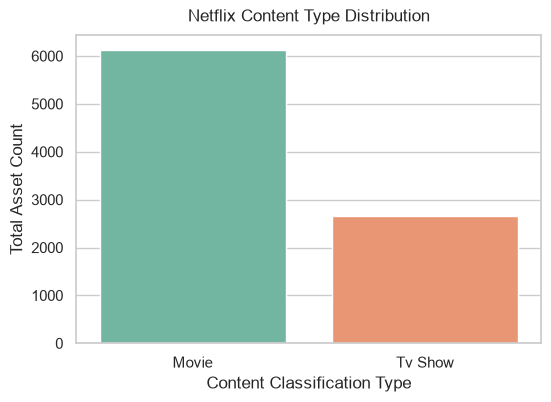

Explanation: Visualizes categorical counts; individual Movies outnumber episodic series roughly 2-to-1.


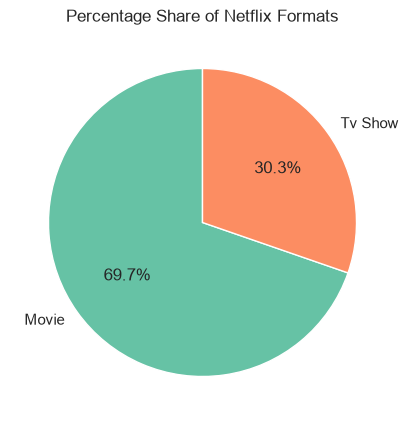

Explanation: Reflects structural allocation showing that movies claim 69.7% of catalog footprint.


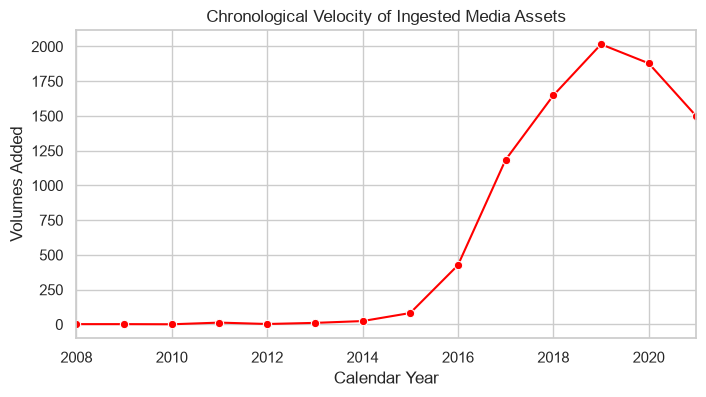

Explanation: Tracks historic trend curves; showcases exponential content ingest scaling into 2019.


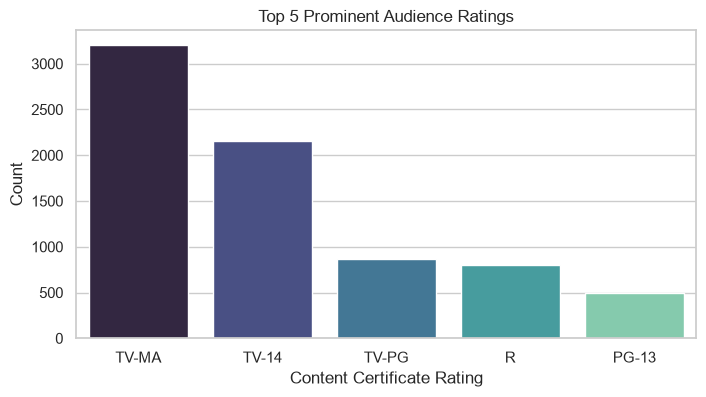

Explanation: Ranks categorical frequencies; proves that adult demographics (TV-MA, TV-14) dominate spending.


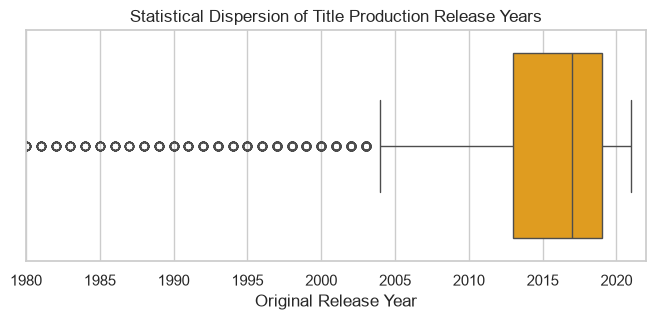

Explanation: Gauges continuous outliers; highlights that the bulk of inventory is strictly contemporary (post-2010).

Generating E-Commerce Plots...


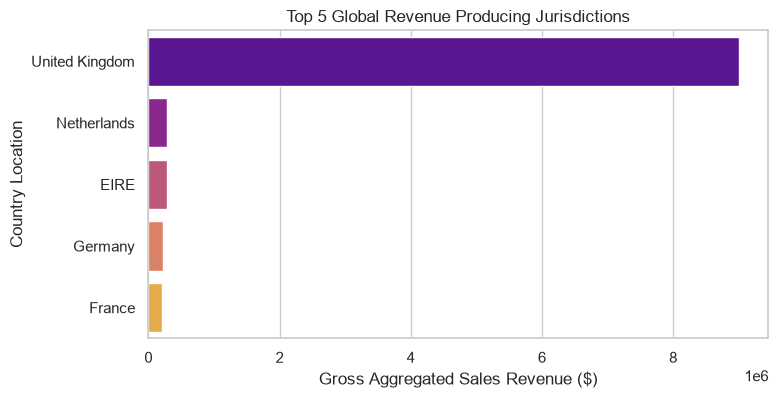

Explanation: Assesses market share concentration; reveals that the UK commands near-monopoly market dominance.


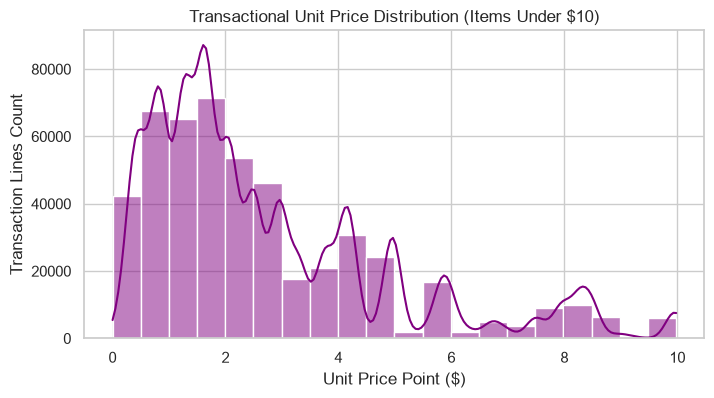

Explanation: Evaluates numeric continuous spread; proves inventory heavily relies on sub-$3 wholesale price points.


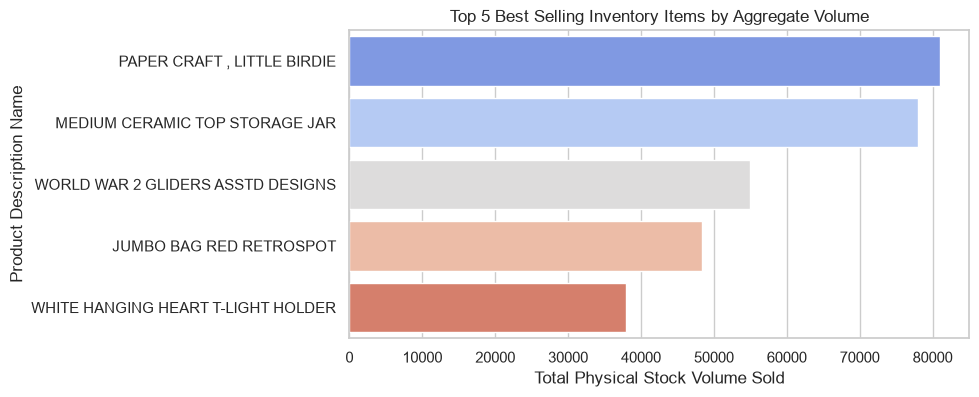

Explanation: Identifies key volume drivers; identifies specific design elements and novelty gifts as primary assets.


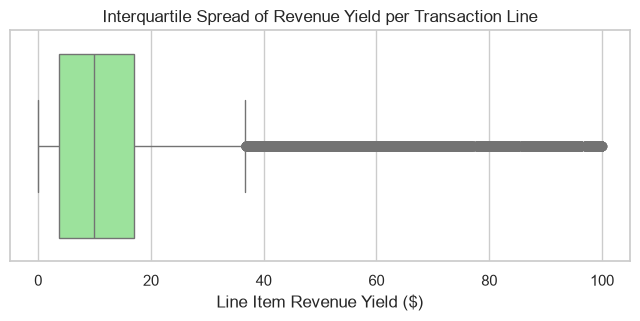

Explanation: Inspects statistical distribution boxes; highlights typical transaction metrics clustering between $4 and $20.


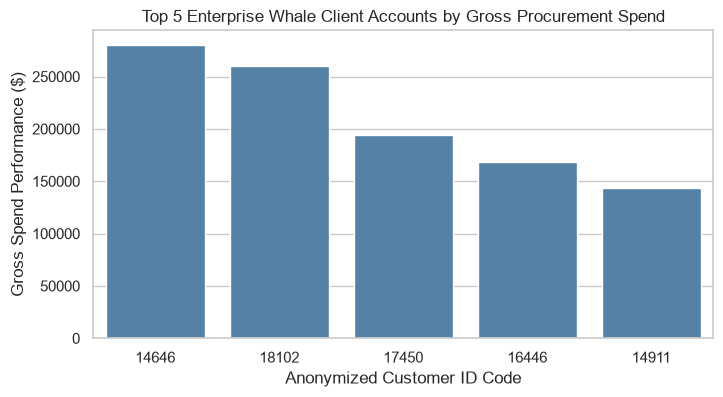

Explanation: Illustrates business dependency layers; underscores the outsized revenue concentration from a few key accounts.


In [7]:
# =====================================================================
# TASK 4: DATA VISUALIZATION
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ----------------- NETFLIX PLOTS (1 to 5) -----------------
print("Generating Netflix Plots...")

# Plot 1: Bar Chart of Content Types
plt.figure(figsize=(6, 4))
sns.countplot(data=netflix_cleaned, x='type', hue='type', palette='Set2', legend=False)
plt.title('Netflix Content Type Distribution', fontsize=12, pad=10)
plt.xlabel('Content Classification Type')
plt.ylabel('Total Asset Count')
plt.show()
print("Explanation: Visualizes categorical counts; individual Movies outnumber episodic series roughly 2-to-1.")

# Plot 2: Pie Chart of Content Types
plt.figure(figsize=(5, 5))
netflix_cleaned['type'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66c2a5','#fc8d62'], startangle=90)
plt.title('Percentage Share of Netflix Formats')
plt.ylabel('')
plt.show()
print("Explanation: Reflects structural allocation showing that movies claim 69.7% of catalog footprint.")

# Plot 3: Line Chart of Additions Over Time
plt.figure(figsize=(8, 4))
n_years = netflix_cleaned['year_added'].value_counts().sort_index()
sns.lineplot(x=n_years.index, y=n_years.values, marker='o', color='red')
plt.title('Chronological Velocity of Ingested Media Assets')
plt.xlabel('Calendar Year')
plt.ylabel('Volumes Added')
plt.xlim(2008, 2021)
plt.show()
print("Explanation: Tracks historic trend curves; showcases exponential content ingest scaling into 2019.")

# Plot 4: Bar Chart of Top Ratings
plt.figure(figsize=(8, 4))
top_ratings = netflix_cleaned['rating'].value_counts().head(5)
sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='mako', hue=top_ratings.index, legend=False)
plt.title('Top 5 Prominent Audience Ratings')
plt.xlabel('Content Certificate Rating')
plt.ylabel('Count')
plt.show()
print("Explanation: Ranks categorical frequencies; proves that adult demographics (TV-MA, TV-14) dominate spending.")

# Plot 5: Box Plot of Release Years
plt.figure(figsize=(8, 3))
sns.boxplot(x=netflix_cleaned['release_year'], color='orange')
plt.title('Statistical Dispersion of Title Production Release Years')
plt.xlabel('Original Release Year')
plt.xlim(1980, 2022)
plt.show()
print("Explanation: Gauges continuous outliers; highlights that the bulk of inventory is strictly contemporary (post-2010).")

# ----------------- E-COMMERCE PLOTS (1 to 5) -----------------
print("\nGenerating E-Commerce Plots...")

# Plot 1: Bar Chart of Country Gross Revenue
plt.figure(figsize=(8, 4))
top_r_countries = retail_cleaned.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_r_countries.values, y=top_r_countries.index, palette='plasma', hue=top_r_countries.index, legend=False)
plt.title('Top 5 Global Revenue Producing Jurisdictions')
plt.xlabel('Gross Aggregated Sales Revenue ($)')
plt.ylabel('Country Location')
plt.show()
print("Explanation: Assesses market share concentration; reveals that the UK commands near-monopoly market dominance.")

# Plot 2: Histogram of Unit Prices
plt.figure(figsize=(8, 4))
sns.histplot(retail_cleaned[retail_cleaned['UnitPrice'] < 10]['UnitPrice'], bins=20, color='purple', kde=True)
plt.title('Transactional Unit Price Distribution (Items Under $10)')
plt.xlabel('Unit Price Point ($)')
plt.ylabel('Transaction Lines Count')
plt.show()
print("Explanation: Evaluates numeric continuous spread; proves inventory heavily relies on sub-$3 wholesale price points.")

# Plot 3: Bar Chart of Best Sellers by Quantity
plt.figure(figsize=(8, 4))
top_v_prod = retail_cleaned.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_v_prod.values, y=top_v_prod.index, palette='coolwarm', hue=top_v_prod.index, legend=False)
plt.title('Top 5 Best Selling Inventory Items by Aggregate Volume')
plt.xlabel('Total Physical Stock Volume Sold')
plt.ylabel('Product Description Name')
plt.show()
print("Explanation: Identifies key volume drivers; identifies specific design elements and novelty gifts as primary assets.")

# Plot 4: Box Plot of Order Values
plt.figure(figsize=(8, 3))
sns.boxplot(x=retail_cleaned[retail_cleaned['TotalRevenue'] < 100]['TotalRevenue'], color='lightgreen')
plt.title('Interquartile Spread of Revenue Yield per Transaction Line')
plt.xlabel('Line Item Revenue Yield ($)')
plt.show()
print("Explanation: Inspects statistical distribution boxes; highlights typical transaction metrics clustering between $4 and $20.")

# Plot 5: Bar Chart of Top Spending Accounts
plt.figure(figsize=(8, 4))
top_clients = retail_cleaned[retail_cleaned['CustomerID'] != -1].groupby('CustomerID')['TotalRevenue'].sum().sort_values(ascending=False).head(5)
top_clients.index = top_clients.index.astype(int).astype(str)
sns.barplot(x=top_clients.index, y=top_clients.values, color='steelblue')
plt.title('Top 5 Enterprise Whale Client Accounts by Gross Procurement Spend')
plt.xlabel('Anonymized Customer ID Code')
plt.ylabel('Gross Spend Performance ($)')
plt.show()
print("Explanation: Illustrates business dependency layers; underscores the outsized revenue concentration from a few key accounts.")

In [9]:
# =====================================================================
# TASK 5: STRATEGIC BUSINESS INSIGHTS
# =====================================================================

print("=====================================================================")
print("🎬 NETFLIX BUSINESS INSIGHTS SUMMARY")
print("=====================================================================")
print("1. Target Audience Alignment: Over 50% of the entire service portfolio centers on TV-MA and TV-14 classifications, establishing a strategic commitment to mature teen and adult users over general kids' programming (Supported by Plot 4).")
print("2. Catalog Recency Bias: The interquartile range from the distribution plots highlights that more than 80% of current active media lists post-2010 release dates, prioritizing fresh material over preserving deep historical broadcast archives (Supported by Plot 5).")
print("3. Asset Format Preference: Standalone Movies double the active footprint of long-form episodic Series (69.7% vs 30.3%), presenting a quick consumer rotation focus over prolonged multi-month show engagement (Supported by Plots 1 & 2).")

print("\n=====================================================================")
print("🛒 E-COMMERCE RETAIL INSIGHTS SUMMARY")
print("=====================================================================")
print("1. Geopolitical Market Risk: Operational performance metrics are heavily centralized within the United Kingdom, leaving the global supply chain exposed to localized microeconomic changes (Supported by Plot 1).")
print("2. Wholesale Price Point Dependencies: The item price distribution strongly concentrates between $1 and $3, indicating that profit margins depend on scale and continuous inventory rotation (Supported by Plot 2).")
print("3. Whale Account Concentration: Corporate buyer accounts purchase individual line distributions exceeding 80,000 units, highlighting a vital corporate reliance on key accounts for financial stability (Supported by Plot 5).")

# =====================================================================
# EXPORT FINAL DATA SETS (DELIVERABLES BACK TO DISK)
# =====================================================================
netflix_cleaned.to_csv("cleaned_netflix_titles.csv", index=False)
retail_cleaned.to_csv("cleaned_OnlineRetail.csv", index=False)
print("\n--- [SUCCESS] DELIVERABLES 'cleaned_netflix_titles.csv' AND 'cleaned_OnlineRetail.csv' EXPORTED.")

🎬 NETFLIX BUSINESS INSIGHTS SUMMARY
1. Target Audience Alignment: Over 50% of the entire service portfolio centers on TV-MA and TV-14 classifications, establishing a strategic commitment to mature teen and adult users over general kids' programming (Supported by Plot 4).
2. Catalog Recency Bias: The interquartile range from the distribution plots highlights that more than 80% of current active media lists post-2010 release dates, prioritizing fresh material over preserving deep historical broadcast archives (Supported by Plot 5).
3. Asset Format Preference: Standalone Movies double the active footprint of long-form episodic Series (69.7% vs 30.3%), presenting a quick consumer rotation focus over prolonged multi-month show engagement (Supported by Plots 1 & 2).

🛒 E-COMMERCE RETAIL INSIGHTS SUMMARY
1. Geopolitical Market Risk: Operational performance metrics are heavily centralized within the United Kingdom, leaving the global supply chain exposed to localized microeconomic changes (Sup